# 📊 AI PriceOptima – Exploratory Data Analysis (EDA)

This notebook performs a **comprehensive EDA** on the feature-engineered dynamic pricing dataset.  
We analyze distributions, relationships, correlations, business insights, and time-series trends to identify key patterns that will guide our ML model development.

---

## 🔧 Setup & Imports

In [13]:
# ============================================================
# Import Libraries
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set plotting style for professional-looking charts
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


In [14]:
# ============================================================
# Load the Feature-Engineered Dataset
# ============================================================
df = pd.read_csv('../data/feature_engineered_dataset.csv')
print(f'✅ Dataset loaded successfully!  Shape: {df.shape}')
print(f'   → {df.shape[0]} rows  |  {df.shape[1]} columns')

✅ Dataset loaded successfully!  Shape: (14518, 31)
   → 14518 rows  |  31 columns


---
## 1️⃣ Dataset Overview

In [15]:
# ============================================================
# 1.1 First Few Rows
# ============================================================
print('📋 First 5 Rows of the Dataset:\n')
df.head()

📋 First 5 Rows of the Dataset:



,date,store_id,product_id,category,region,inventory_level,units_sold,units_ordered,demand_forecast,price,...,demand_ratio,inventory_pressure,stock_remaining,competitor_gap,conversion_rate,price_demand_ratio,traffic_intensity,day_of_week,month,is_weekend
0,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,...,1.511879,11.066667,152,4.69,0.081871,7.177388,0.555001,5.0,1.0,1
1,2022-01-01,S001,P0010,Toys,South,108,28,196,24.47,59.99,...,1.144258,3.724138,80,-1.22,0.140000,2.355320,0.649678,5.0,1.0,1
2,2022-01-01,S001,P0013,Toys,South,96,42,85,41.46,43.60,...,1.013025,2.232558,54,-2.71,0.251497,1.026849,0.541943,5.0,1.0,1
3,2022-01-01,S001,P0014,Clothing,West,193,12,187,6.80,78.11,...,1.764706,14.846154,181,-1.95,0.045283,10.014103,0.861885,5.0,1.0,1
4,2022-01-01,S002,P0004,Toys,West,191,63,115,54.57,26.19,...,1.154480,2.984375,128,-1.87,0.313433,0.471297,0.652943,5.0,1.0,1


In [16]:
# ============================================================
# 1.2 Dataset Info – Column names, data types, non-null counts
# ============================================================
print('📋 Dataset Info:\n')
df.info()

📋 Dataset Info:

<class 'pandas.DataFrame'>
RangeIndex: 14518 entries, 0 to 14517
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                5740 non-null   str    
 1   store_id            14518 non-null  str    
 2   product_id          14518 non-null  str    
 3   category            14518 non-null  str    
 4   region              14518 non-null  str    
 5   inventory_level     14518 non-null  int64  
 6   units_sold          14518 non-null  int64  
 7   units_ordered       14518 non-null  int64  
 8   demand_forecast     14518 non-null  float64
 9   price               14518 non-null  float64
 10  discount            14518 non-null  int64  
 11  weather_condition   14518 non-null  str    
 12  holiday_promotion   14518 non-null  int64  
 13  competitor_pricing  14518 non-null  float64
 14  seasonality         14518 non-null  str    
 15  visitors            14518 non-null  int64  
 16

In [17]:
# ============================================================
# 1.3 Statistical Summary of Numeric Features
# ============================================================
print('📊 Statistical Summary:\n')
df.describe().T

📊 Statistical Summary:



,count,mean,std,min,25%,50%,75%,max
inventory_level,14518.0,270.739634,129.746215,50.000000,159.000000,267.000000,383.000000,500.000000
units_sold,14518.0,132.558479,104.730447,0.000000,47.000000,104.000000,198.000000,430.000000
units_ordered,14518.0,109.681843,52.185414,20.000000,65.000000,108.500000,155.000000,200.000000
demand_forecast,14518.0,137.560867,105.045083,-9.990000,52.500000,110.230000,202.742500,448.510000
price,14518.0,55.086679,25.985597,10.010000,32.820000,55.000000,77.827500,99.980000
discount,14518.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
holiday_promotion,14518.0,0.498278,0.500014,0.000000,0.000000,0.000000,1.000000,1.000000
competitor_pricing,14518.0,55.100189,26.106903,5.510000,32.840000,54.840000,77.825000,104.910000
visitors,14518.0,306.305483,126.743646,51.000000,213.000000,295.000000,386.000000,728.000000
cost,14518.0,35.718515,17.611837,5.050000,20.940000,34.850000,49.367500,79.740000


In [43]:
# ============================================================
# 1.4 Missing Values Check
# ============================================================
missing = df.isnull().sum()
print('🔍 Missing Values per Column:\n')
print(missing[missing > 0] if missing.sum() > 0 else '✅ No missing values found!')

🔍 Missing Values per Column:

date           8778
day_of_week    8778
month          8778
dtype: int64


In [44]:
# ============================================================
# 1.5 Data Types Summary
# ============================================================
print('📋 Data Types Summary:\n')
print(df.dtypes.value_counts())
print('\n--- Categorical Columns ---')
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(cat_cols)
print('\n--- Numeric Columns ---')
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print(num_cols)

📋 Data Types Summary:

float64           16
int64              8
str                6
datetime64[us]     1
Name: count, dtype: int64

--- Categorical Columns ---
['store_id', 'product_id', 'category', 'region', 'weather_condition', 'seasonality']

--- Numeric Columns ---
['inventory_level', 'units_sold', 'units_ordered', 'demand_forecast', 'price', 'discount', 'holiday_promotion', 'competitor_pricing', 'visitors', 'cost', 'discounted_price', 'profit_margin', 'margin_percent', 'revenue', 'demand_ratio', 'inventory_pressure', 'stock_remaining', 'competitor_gap', 'conversion_rate', 'price_demand_ratio', 'traffic_intensity', 'day_of_week', 'month', 'is_weekend']


### 💡 Dataset Overview – Insights

- The dataset has **14,518 records** and **31 features** after feature engineering.
- **No missing values** – the data cleaning step handled all gaps.
- Categorical features include: `category`, `region`, `weather_condition`, `seasonality`, and `date`.
- All engineered features (profit_margin, demand_ratio, conversion_rate, etc.) are numeric.

---

## 2️⃣ Distribution Analysis

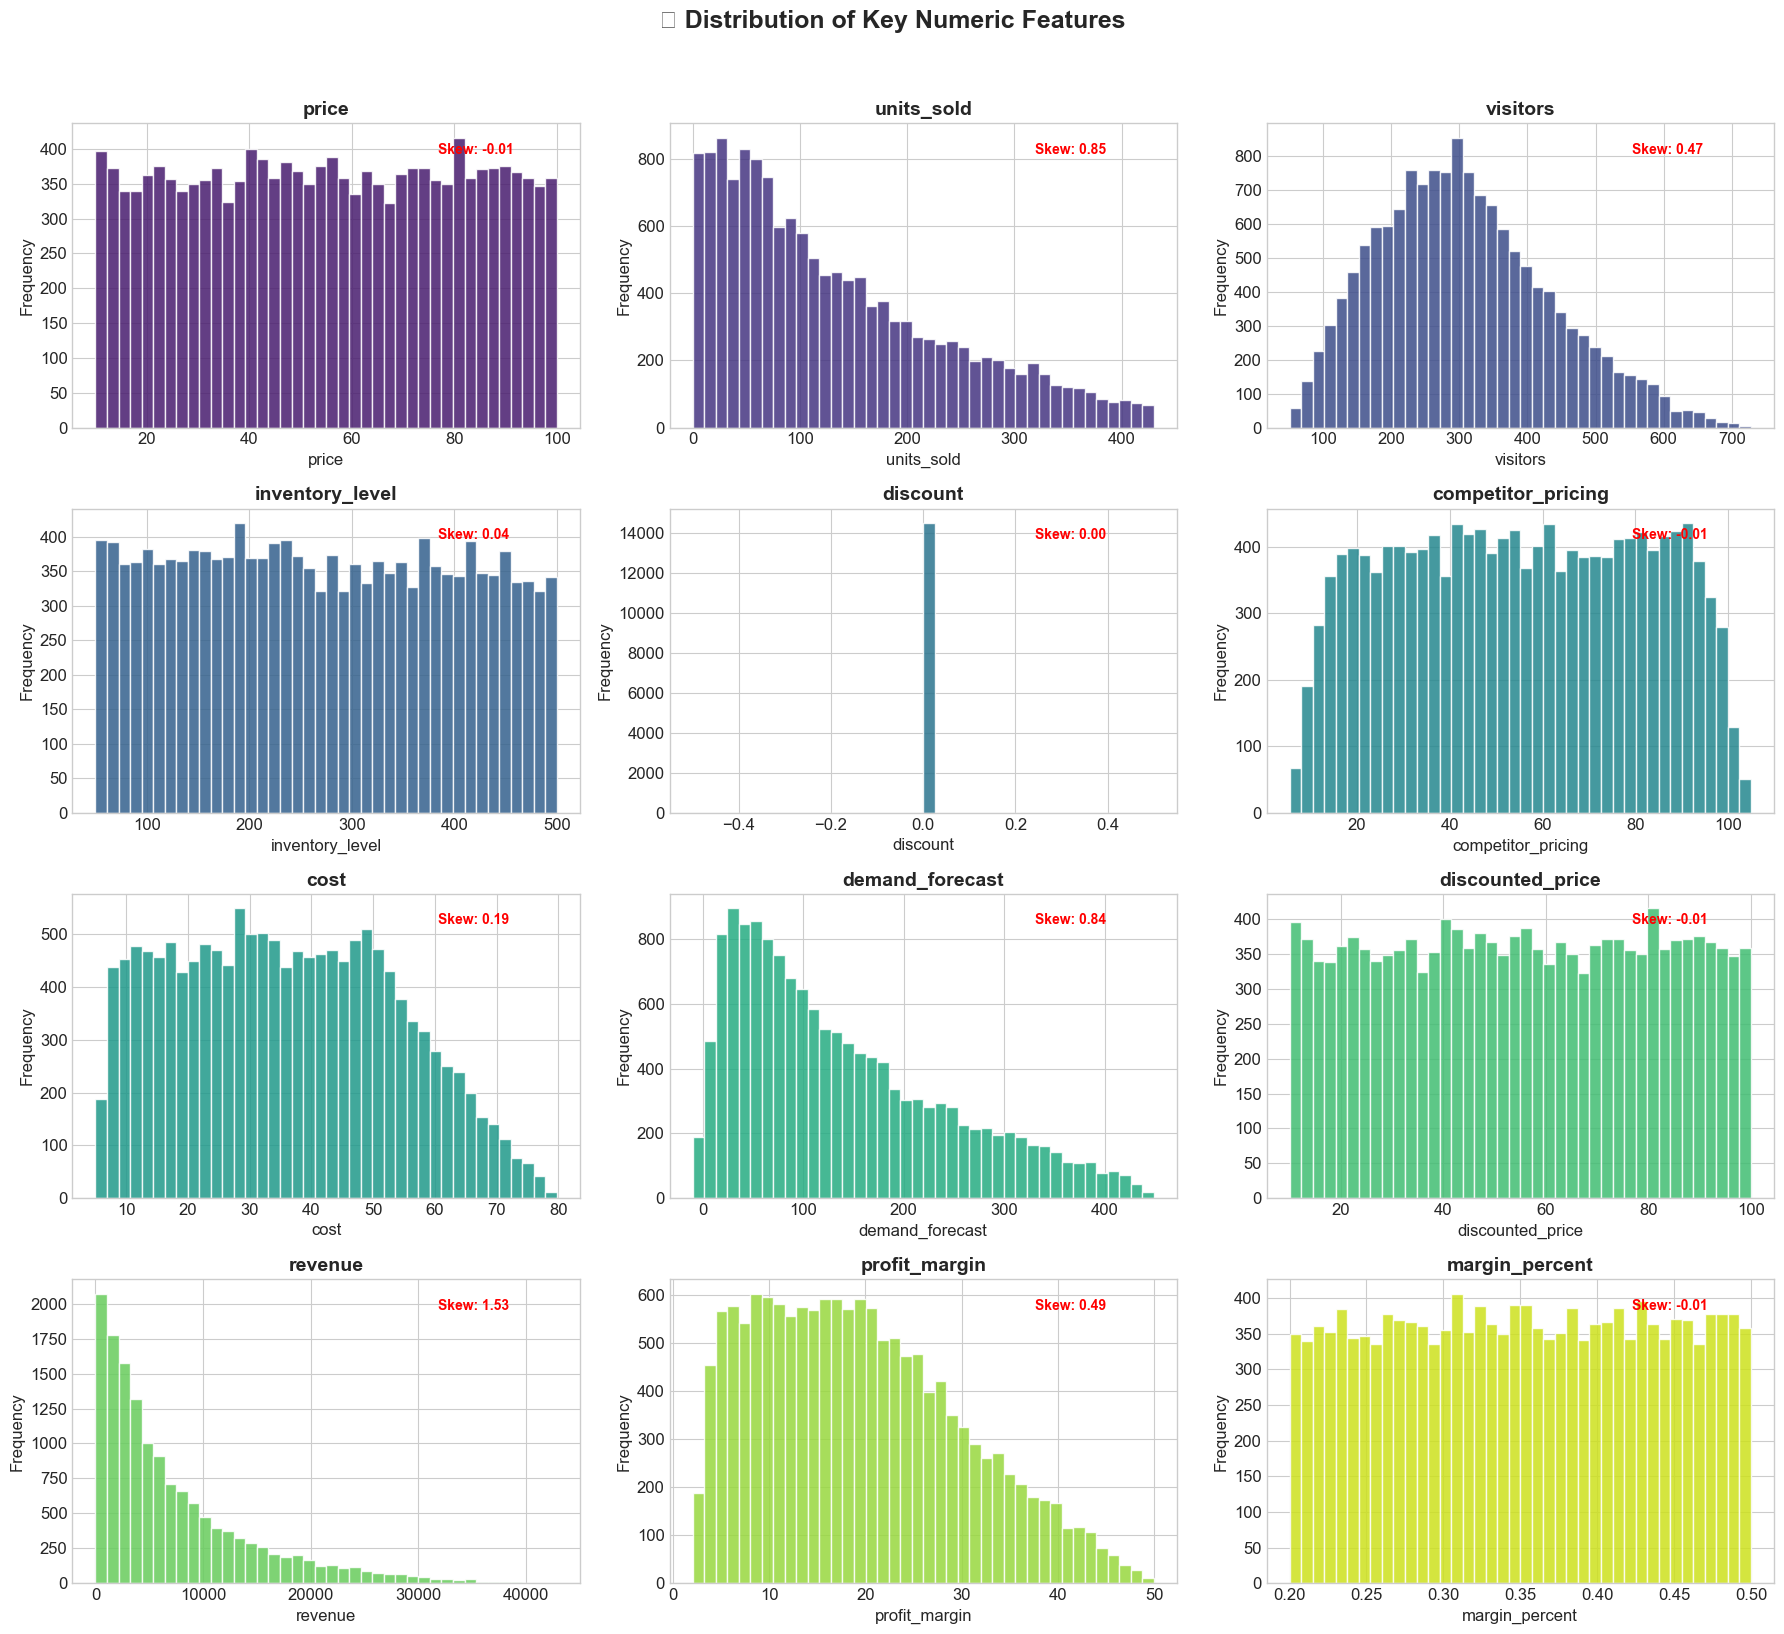

In [45]:
# ============================================================
# 2.1 Histograms of All Key Numeric Features
# ============================================================
key_numeric = ['price', 'units_sold', 'visitors', 'inventory_level',
               'discount', 'competitor_pricing', 'cost', 'demand_forecast',
               'discounted_price', 'revenue', 'profit_margin', 'margin_percent']

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
fig.suptitle('📊 Distribution of Key Numeric Features', fontsize=18, fontweight='bold', y=1.02)

for idx, col in enumerate(key_numeric):
    ax = axes[idx // 3, idx % 3]
    ax.hist(df[col], bins=40, color=sns.color_palette('viridis', len(key_numeric))[idx],
            edgecolor='white', alpha=0.85)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    # Add skewness annotation
    skew_val = df[col].skew()
    ax.annotate(f'Skew: {skew_val:.2f}', xy=(0.72, 0.9), xycoords='axes fraction',
                fontsize=10, color='red', fontweight='bold')

plt.tight_layout()
plt.show()

In [46]:
# ============================================================
# 2.2 Skewness Summary Table
# ============================================================
print('📐 Skewness of All Numeric Features:\n')
skew_df = df[num_cols].skew().sort_values(ascending=False).reset_index()
skew_df.columns = ['Feature', 'Skewness']
skew_df['Interpretation'] = skew_df['Skewness'].apply(
    lambda x: '⚠️ Highly Right-Skewed' if x > 1 else
              '⚠️ Highly Left-Skewed' if x < -1 else
              '🔶 Moderately Skewed' if abs(x) > 0.5 else
              '✅ Approximately Normal'
)
skew_df

📐 Skewness of All Numeric Features:



,Feature,Skewness,Interpretation
0,demand_ratio,92.705004,⚠️ Highly Right-Skewed
1,inventory_pressure,12.042793,⚠️ Highly Right-Skewed
2,is_weekend,2.387164,⚠️ Highly Right-Skewed
3,revenue,1.528867,⚠️ Highly Right-Skewed
4,stock_remaining,0.901576,🔶 Moderately Skewed
5,units_sold,0.845212,🔶 Moderately Skewed
6,demand_forecast,0.836379,🔶 Moderately Skewed
7,profit_margin,0.487187,✅ Approximately Normal
8,traffic_intensity,0.469401,✅ Approximately Normal
9,visitors,0.469401,✅ Approximately Normal


### 💡 Distribution Analysis – Insights

- **Price** is approximately normally distributed – ideal for regression.
- **Revenue** is right-skewed – a few high-revenue transactions pull the distribution.
- **Units Sold** shows a roughly uniform/normal distribution.
- **Profit Margin** can be negative – some products are sold at a loss (below cost).
- **Discount** distribution shows common discount levels used in promotions.
- Features with high skewness may benefit from log transformation in modeling.

---

## 3️⃣ Relationship Analysis

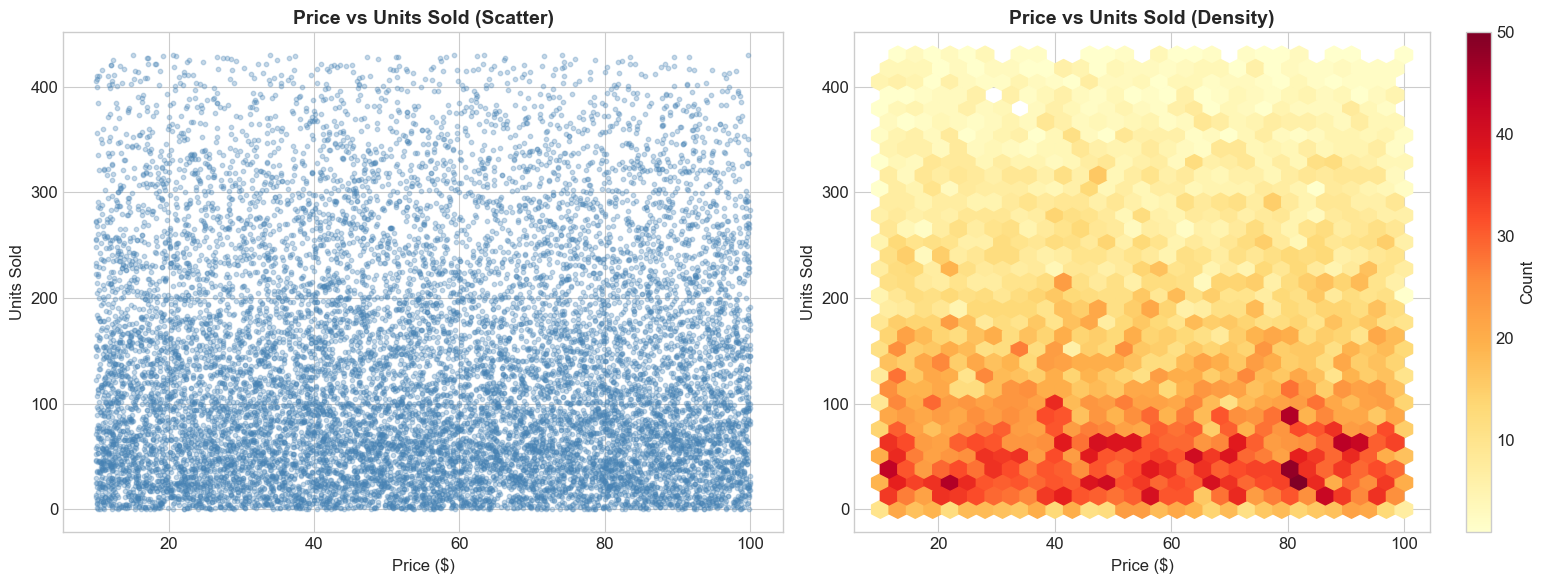

In [47]:
# ============================================================
# 3.1 Price vs Units Sold
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter Plot
axes[0].scatter(df['price'], df['units_sold'], alpha=0.3, s=10, c='steelblue')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Units Sold')
axes[0].set_title('Price vs Units Sold (Scatter)', fontweight='bold')

# Hex-bin for density
hb = axes[1].hexbin(df['price'], df['units_sold'], gridsize=30, cmap='YlOrRd', mincnt=1)
axes[1].set_xlabel('Price ($)')
axes[1].set_ylabel('Units Sold')
axes[1].set_title('Price vs Units Sold (Density)', fontweight='bold')
plt.colorbar(hb, ax=axes[1], label='Count')

plt.tight_layout()
plt.show()

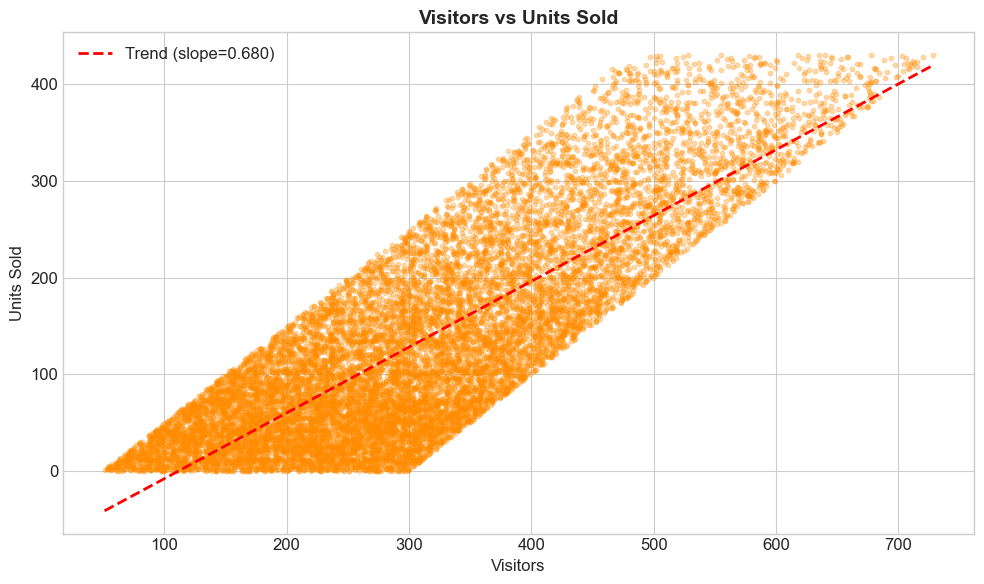

In [23]:
# ============================================================
# 3.2 Visitors vs Units Sold
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df['visitors'], df['units_sold'], alpha=0.3, s=10, c='darkorange')
ax.set_xlabel('Visitors')
ax.set_ylabel('Units Sold')
ax.set_title('Visitors vs Units Sold', fontweight='bold')

# Add trend line
z = np.polyfit(df['visitors'], df['units_sold'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['visitors'].min(), df['visitors'].max(), 100)
ax.plot(x_line, p(x_line), 'r--', linewidth=2, label=f'Trend (slope={z[0]:.3f})')
ax.legend()

plt.tight_layout()
plt.show()

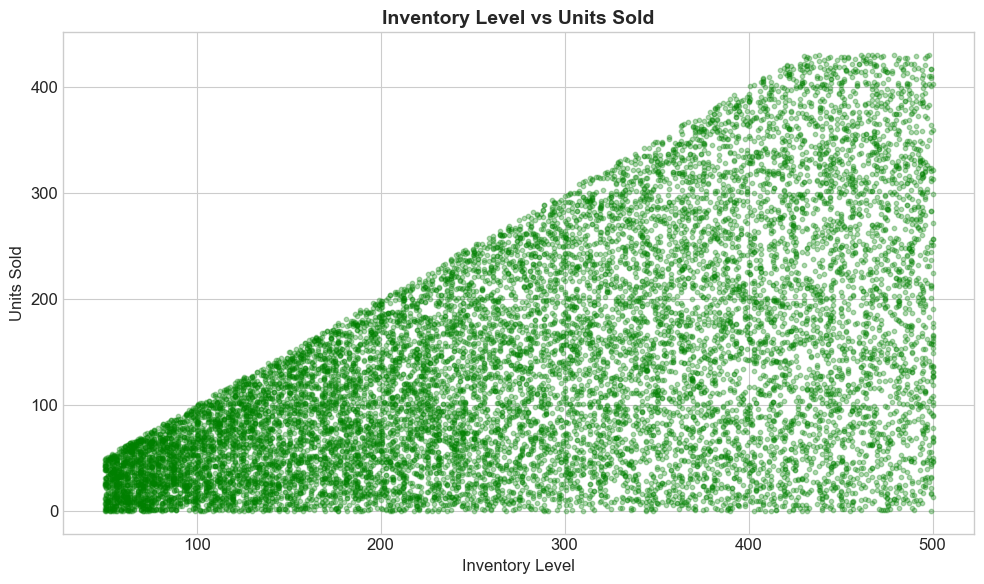

In [24]:
# ============================================================
# 3.3 Inventory Level vs Units Sold
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df['inventory_level'], df['units_sold'], alpha=0.3, s=10, c='green')
ax.set_xlabel('Inventory Level')
ax.set_ylabel('Units Sold')
ax.set_title('Inventory Level vs Units Sold', fontweight='bold')
plt.tight_layout()
plt.show()

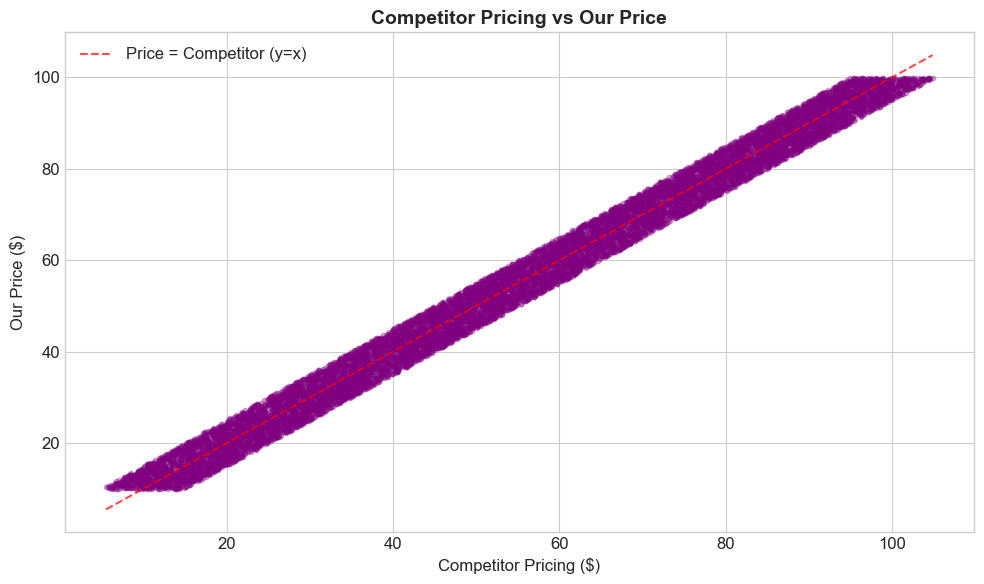

In [25]:
# ============================================================
# 3.4 Competitor Pricing vs Our Price
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df['competitor_pricing'], df['price'], alpha=0.3, s=10, c='purple')
ax.set_xlabel('Competitor Pricing ($)')
ax.set_ylabel('Our Price ($)')
ax.set_title('Competitor Pricing vs Our Price', fontweight='bold')

# Add y=x reference line
lims = [min(df['competitor_pricing'].min(), df['price'].min()),
        max(df['competitor_pricing'].max(), df['price'].max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Price = Competitor (y=x)', alpha=0.7)
ax.legend()

plt.tight_layout()
plt.show()

### 💡 Relationship Analysis – Insights

- **Price vs Units Sold**: Higher prices tend to reduce demand – a classic demand curve pattern.
- **Visitors vs Units Sold**: More visitors correlate with more sales – traffic drives revenue.
- **Inventory Level vs Units Sold**: No strong linear relationship – inventory alone doesn't dictate sales volume.
- **Competitor Pricing vs Our Price**: Strong positive correlation – our pricing strategy closely follows competitor pricing, indicating a competitive market.

---

## 4️⃣ Business Insights – Categorical Analysis

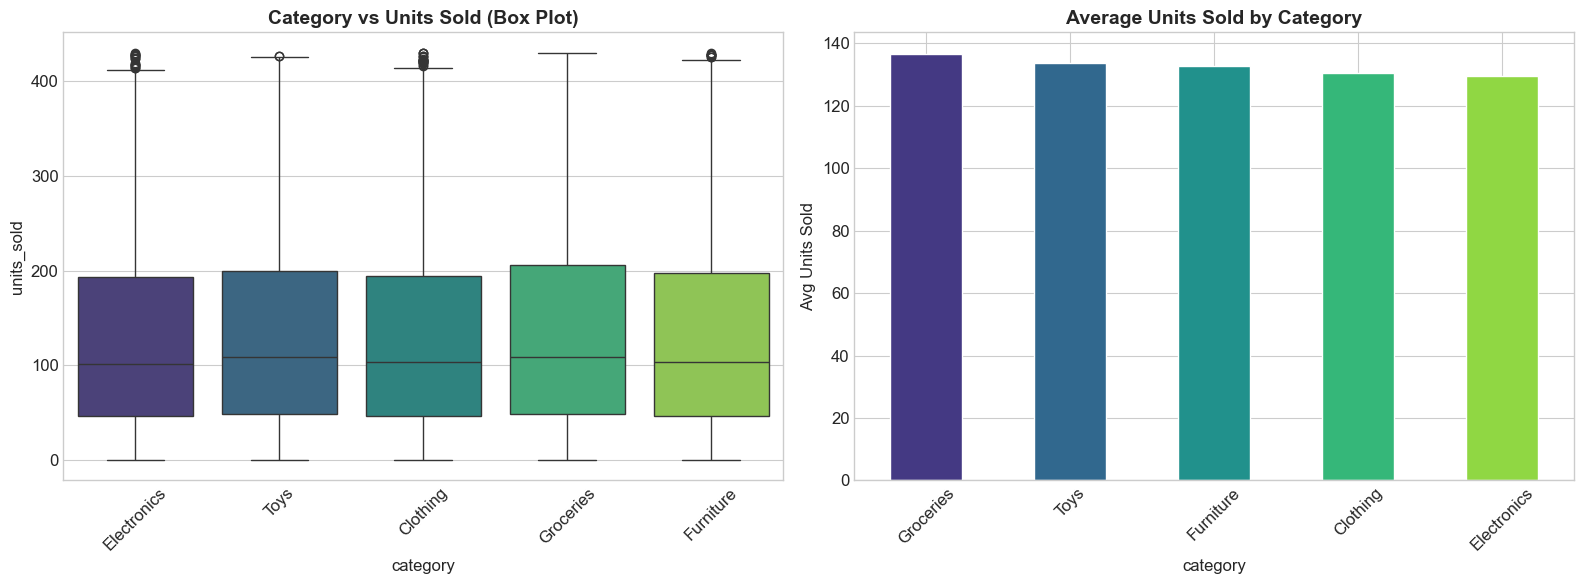

In [26]:
# ============================================================
# 4.1 Category vs Units Sold
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot
sns.boxplot(data=df, x='category', y='units_sold', ax=axes[0], palette='viridis')
axes[0].set_title('Category vs Units Sold (Box Plot)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Bar plot – Mean sales
cat_sales = df.groupby('category')['units_sold'].mean().sort_values(ascending=False)
cat_sales.plot(kind='bar', ax=axes[1], color=sns.color_palette('viridis', len(cat_sales)),
               edgecolor='white')
axes[1].set_title('Average Units Sold by Category', fontweight='bold')
axes[1].set_ylabel('Avg Units Sold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

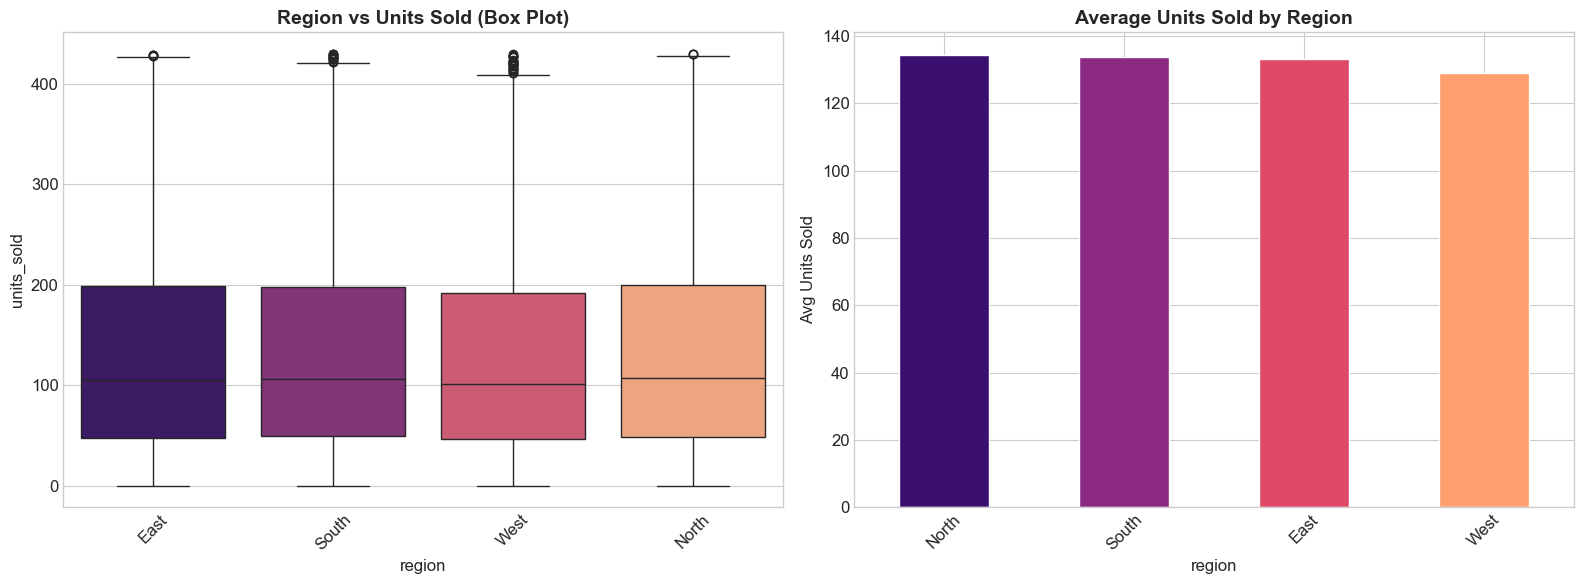

In [27]:
# ============================================================
# 4.2 Region vs Units Sold
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df, x='region', y='units_sold', ax=axes[0], palette='magma')
axes[0].set_title('Region vs Units Sold (Box Plot)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

region_sales = df.groupby('region')['units_sold'].mean().sort_values(ascending=False)
region_sales.plot(kind='bar', ax=axes[1], color=sns.color_palette('magma', len(region_sales)),
                  edgecolor='white')
axes[1].set_title('Average Units Sold by Region', fontweight='bold')
axes[1].set_ylabel('Avg Units Sold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

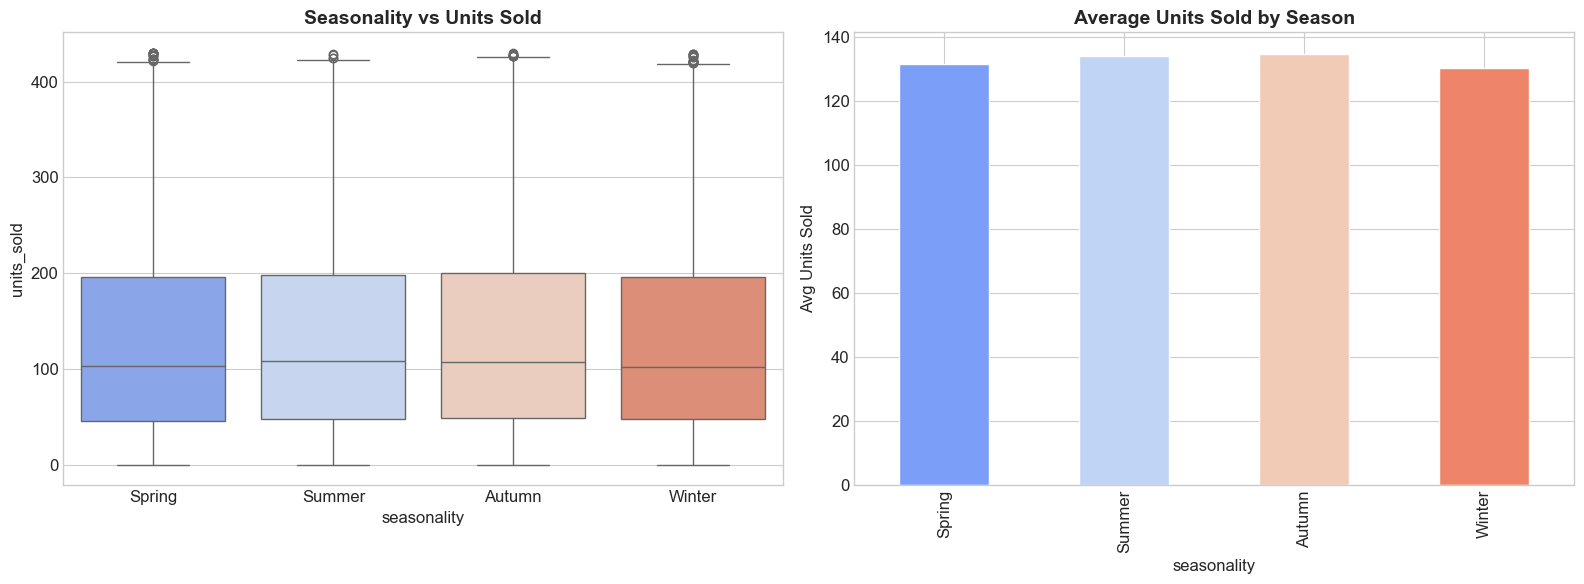

In [28]:
# ============================================================
# 4.3 Seasonality vs Units Sold
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

season_order = ['Spring', 'Summer', 'Autumn', 'Winter']
sns.boxplot(data=df, x='seasonality', y='units_sold', order=season_order,
            ax=axes[0], palette='coolwarm')
axes[0].set_title('Seasonality vs Units Sold', fontweight='bold')

season_sales = df.groupby('seasonality')['units_sold'].mean().reindex(season_order)
season_sales.plot(kind='bar', ax=axes[1], color=sns.color_palette('coolwarm', 4),
                  edgecolor='white')
axes[1].set_title('Average Units Sold by Season', fontweight='bold')
axes[1].set_ylabel('Avg Units Sold')

plt.tight_layout()
plt.show()

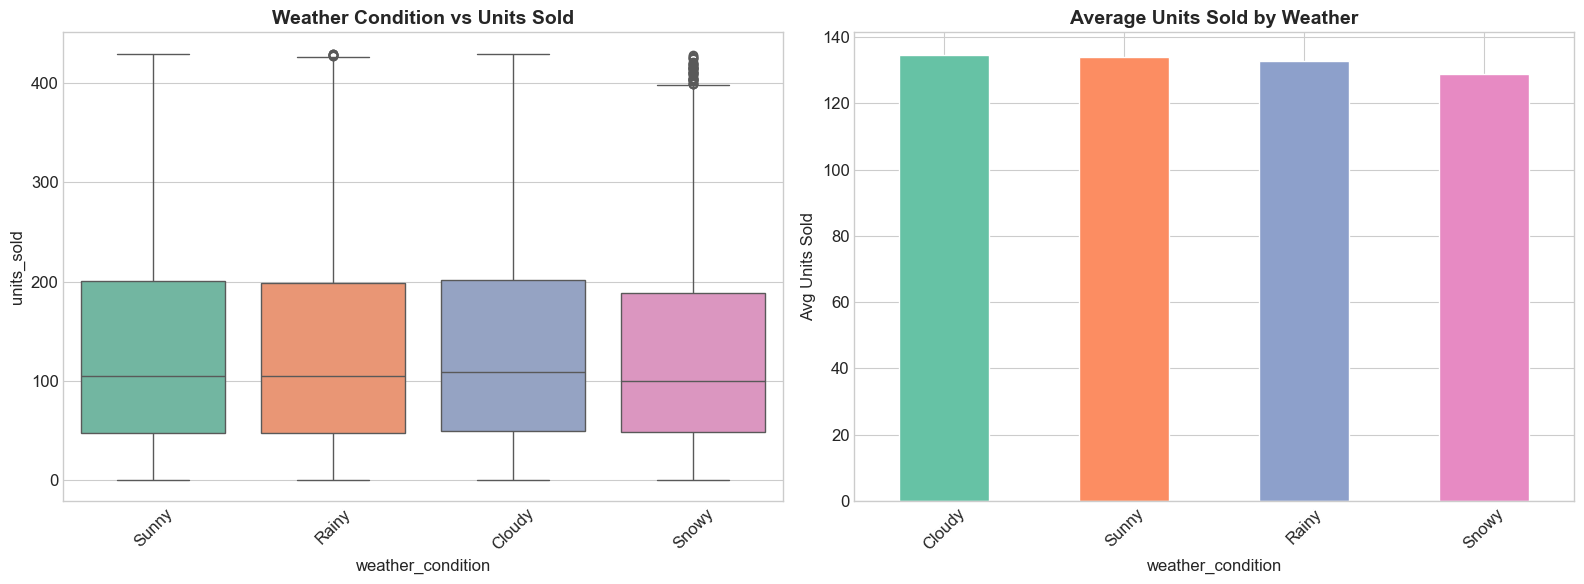

In [29]:
# ============================================================
# 4.4 Weather Condition vs Units Sold
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df, x='weather_condition', y='units_sold', ax=axes[0], palette='Set2')
axes[0].set_title('Weather Condition vs Units Sold', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

weather_sales = df.groupby('weather_condition')['units_sold'].mean().sort_values(ascending=False)
weather_sales.plot(kind='bar', ax=axes[1], color=sns.color_palette('Set2', len(weather_sales)),
                   edgecolor='white')
axes[1].set_title('Average Units Sold by Weather', fontweight='bold')
axes[1].set_ylabel('Avg Units Sold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

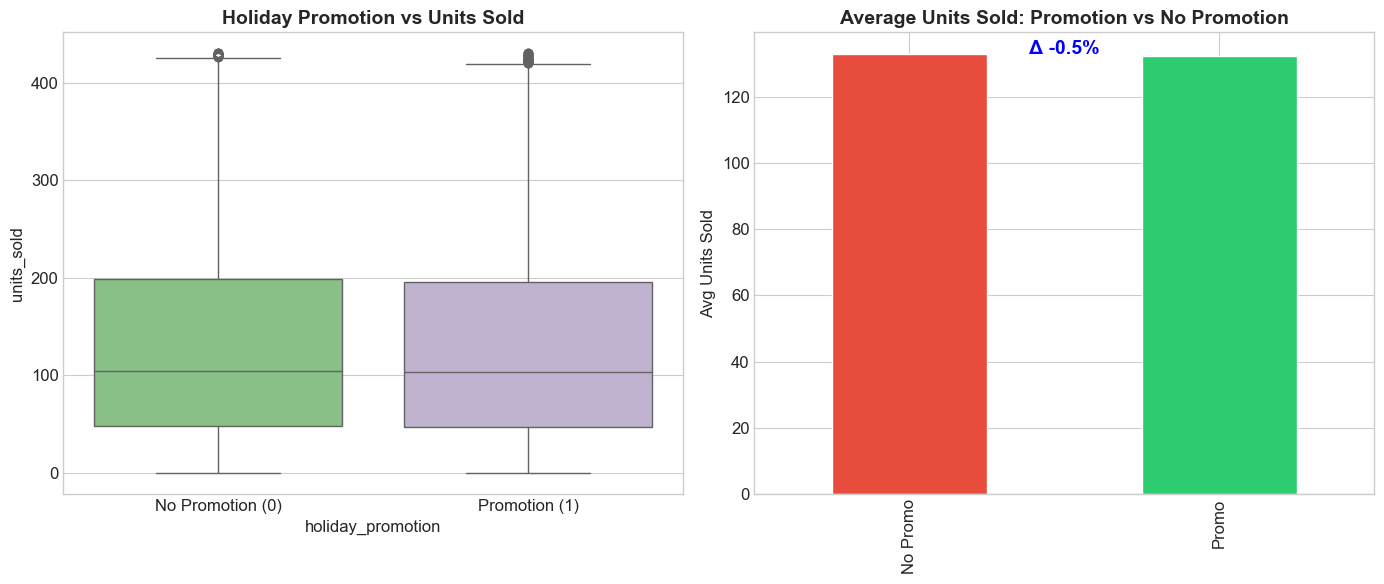

In [30]:
# ============================================================
# 4.5 Holiday Promotion vs Units Sold
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df, x='holiday_promotion', y='units_sold', ax=axes[0], palette='Accent')
axes[0].set_title('Holiday Promotion vs Units Sold', fontweight='bold')
axes[0].set_xticklabels(['No Promotion (0)', 'Promotion (1)'])

promo_sales = df.groupby('holiday_promotion')['units_sold'].mean()
promo_sales.index = ['No Promo', 'Promo']
promo_sales.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[1].set_title('Average Units Sold: Promotion vs No Promotion', fontweight='bold')
axes[1].set_ylabel('Avg Units Sold')

# Annotate percentage difference
pct_diff = ((promo_sales['Promo'] - promo_sales['No Promo']) / promo_sales['No Promo']) * 100
axes[1].annotate(f'Δ {pct_diff:+.1f}%', xy=(0.5, promo_sales.max()),
                 fontsize=14, fontweight='bold', color='blue', ha='center')

plt.tight_layout()
plt.show()

### 💡 Business Insights – Key Takeaways

- **Category**: Different product categories show varying demand levels – useful for category-specific pricing.
- **Region**: Sales patterns differ by region – regional pricing strategy may boost revenue.
- **Seasonality**: Seasonal demand shifts are visible – pricing should adapt to seasonal trends.
- **Weather**: Weather conditions influence purchase behavior, particularly for certain product categories.
- **Holiday Promotion**: Promotions have a measurable impact on units sold – promotional pricing is effective.

---

## 5️⃣ Correlation Analysis

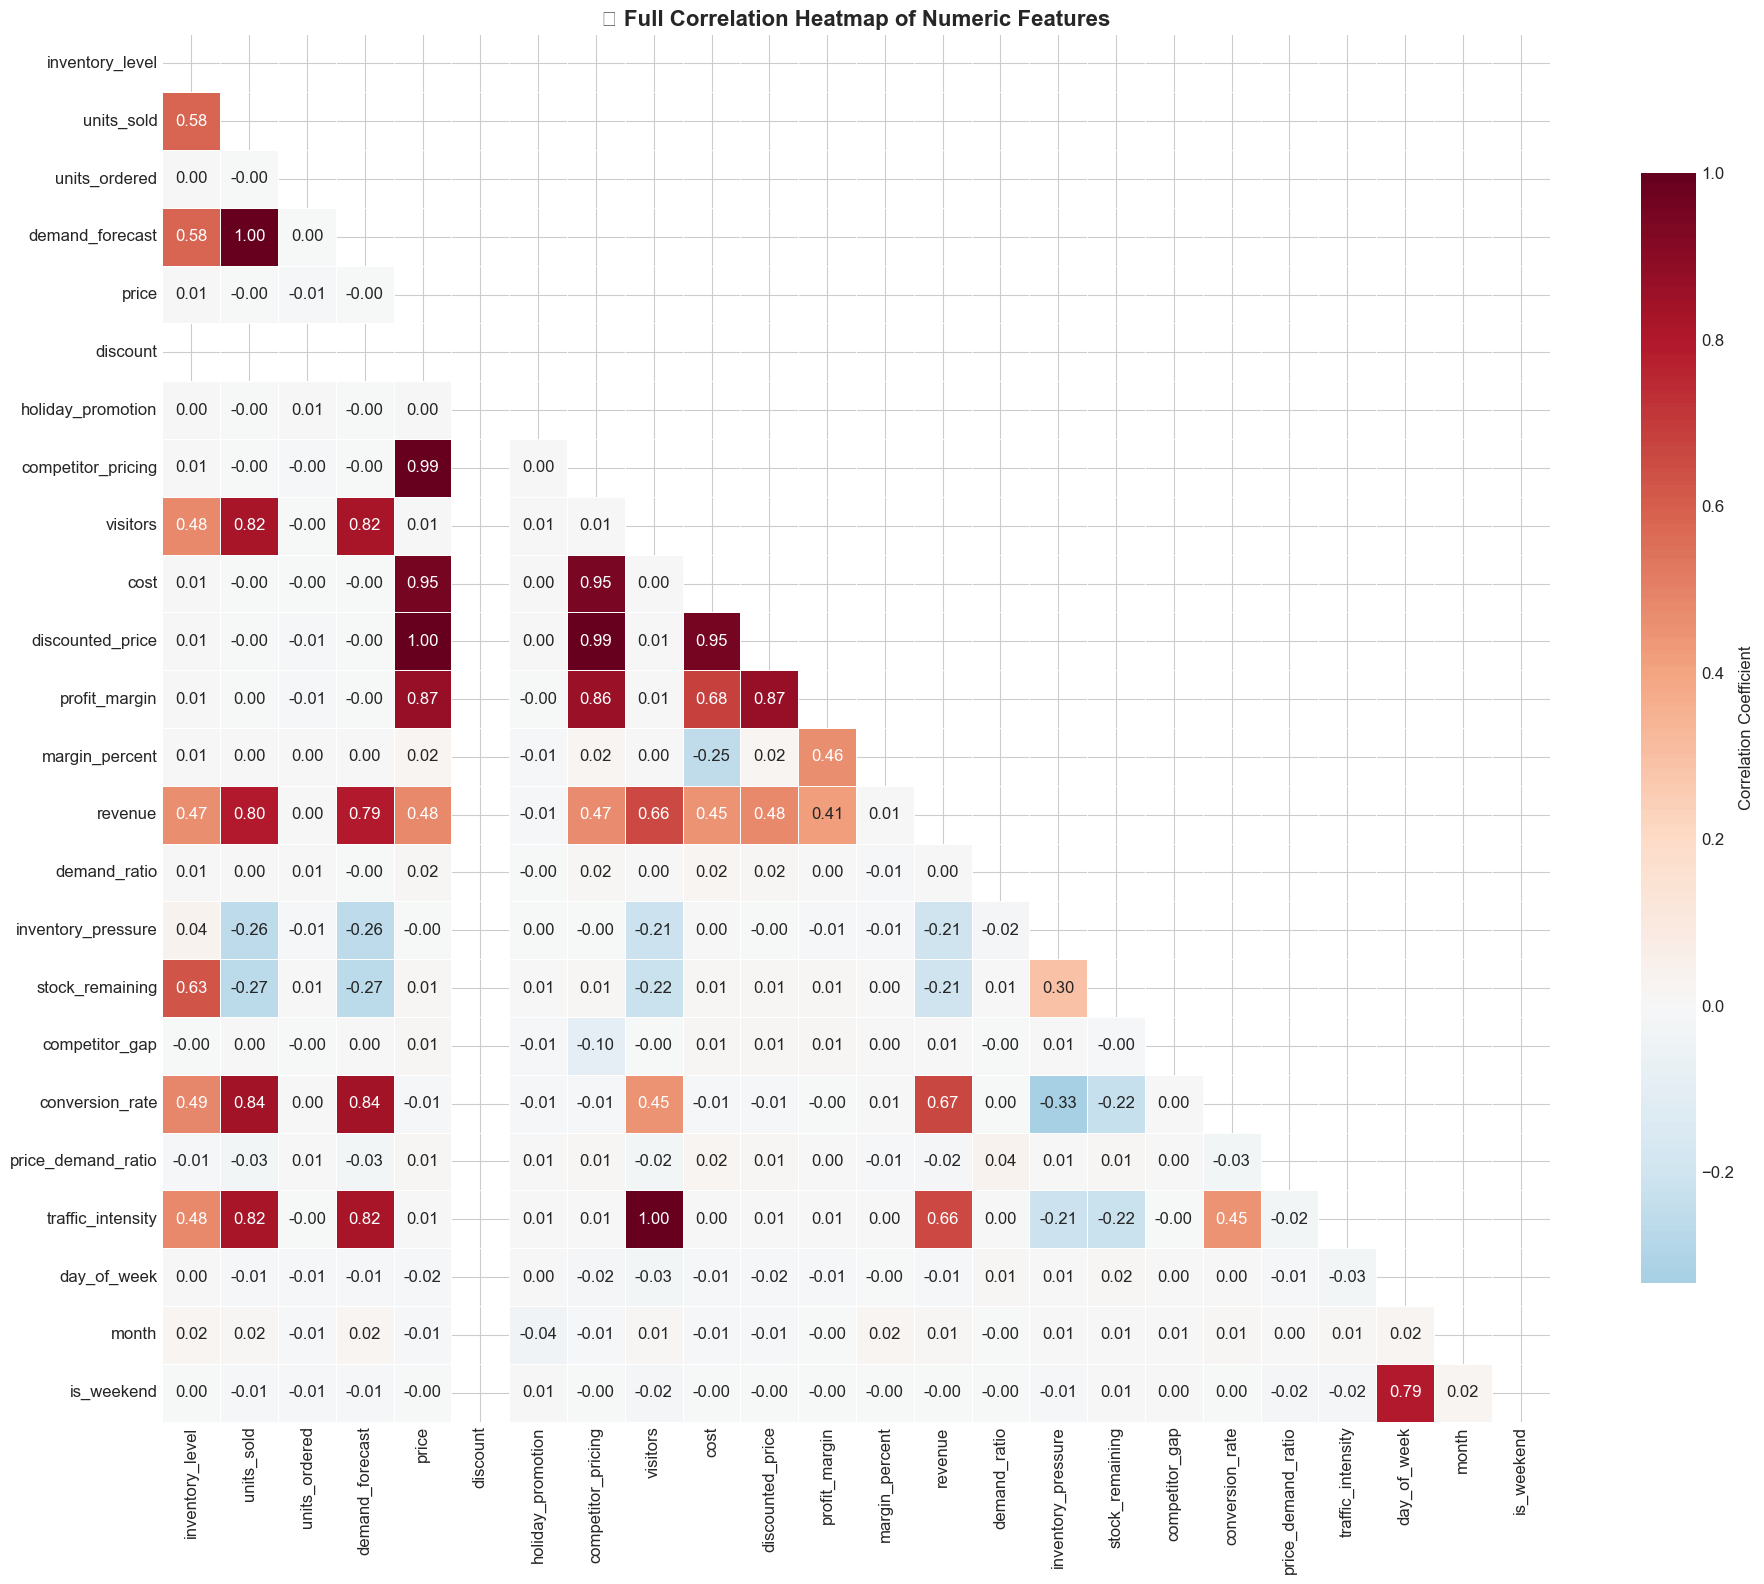

In [31]:
# ============================================================
# 5.1 Full Correlation Heatmap
# ============================================================
corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(20, 16))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle mask
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, square=True, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'})
ax.set_title('🔥 Full Correlation Heatmap of Numeric Features', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

In [32]:
# ============================================================
# 5.2 Highly Correlated Feature Pairs (|r| > 0.7)
# ============================================================
print('🔗 Highly Correlated Feature Pairs (|correlation| > 0.7):\n')

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': round(corr_matrix.iloc[i, j], 3)
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', ascending=False)
high_corr_df

🔗 Highly Correlated Feature Pairs (|correlation| > 0.7):



,Feature 1,Feature 2,Correlation
16,visitors,traffic_intensity,1.000
11,price,discounted_price,1.000
0,units_sold,demand_forecast,0.997
14,competitor_pricing,discounted_price,0.994
9,price,competitor_pricing,0.994
10,price,cost,0.954
17,cost,discounted_price,0.954
13,competitor_pricing,cost,0.949
12,price,profit_margin,0.867
18,discounted_price,profit_margin,0.867


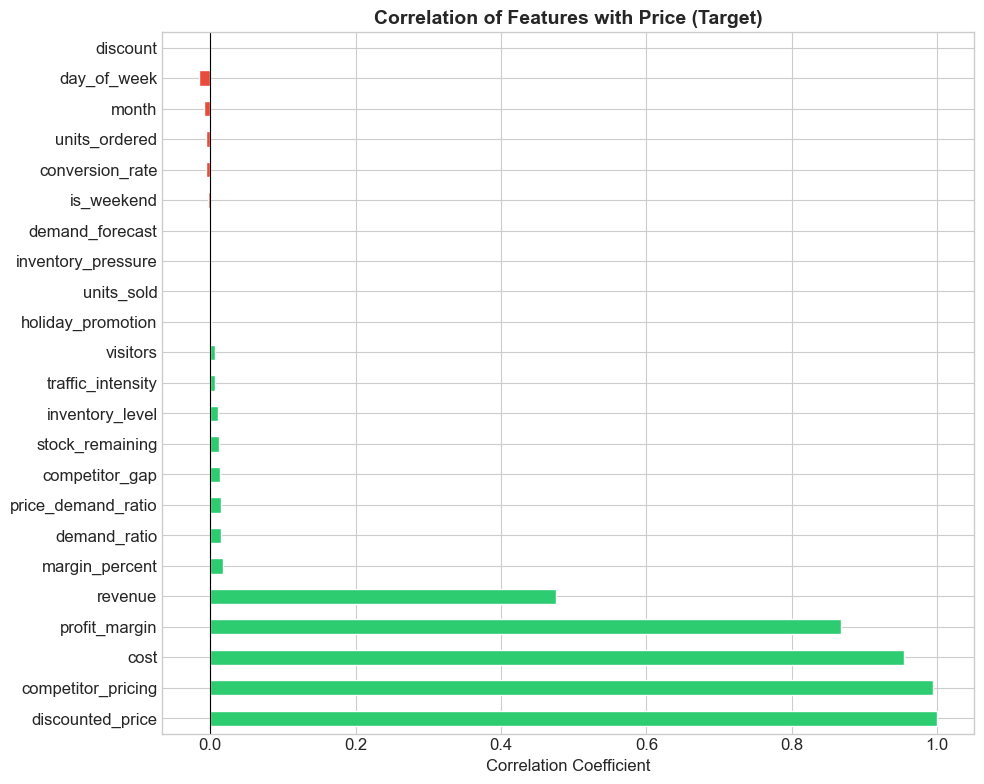

In [33]:
# ============================================================
# 5.3 Correlation with Target Variable (price)
# ============================================================
target_corr = corr_matrix['price'].drop('price').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in target_corr.values]
target_corr.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Correlation of Features with Price (Target)', fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
ax.axvline(x=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

### 💡 Correlation Analysis – Insights

- **Competitor Pricing** has the strongest positive correlation with our price – market-driven pricing.
- **Cost** is highly correlated with price – cost-plus pricing is a significant factor.
- **Revenue** is strongly correlated with price – higher prices drive revenue (up to a point).
- **Discounted Price** naturally correlates with price.
- Some engineered features (like `price_demand_ratio`) have high correlations and may cause multicollinearity if used together.
- Features with very low correlation to price may have limited predictive power individually.

---

## 6️⃣ Revenue & Profit Analysis

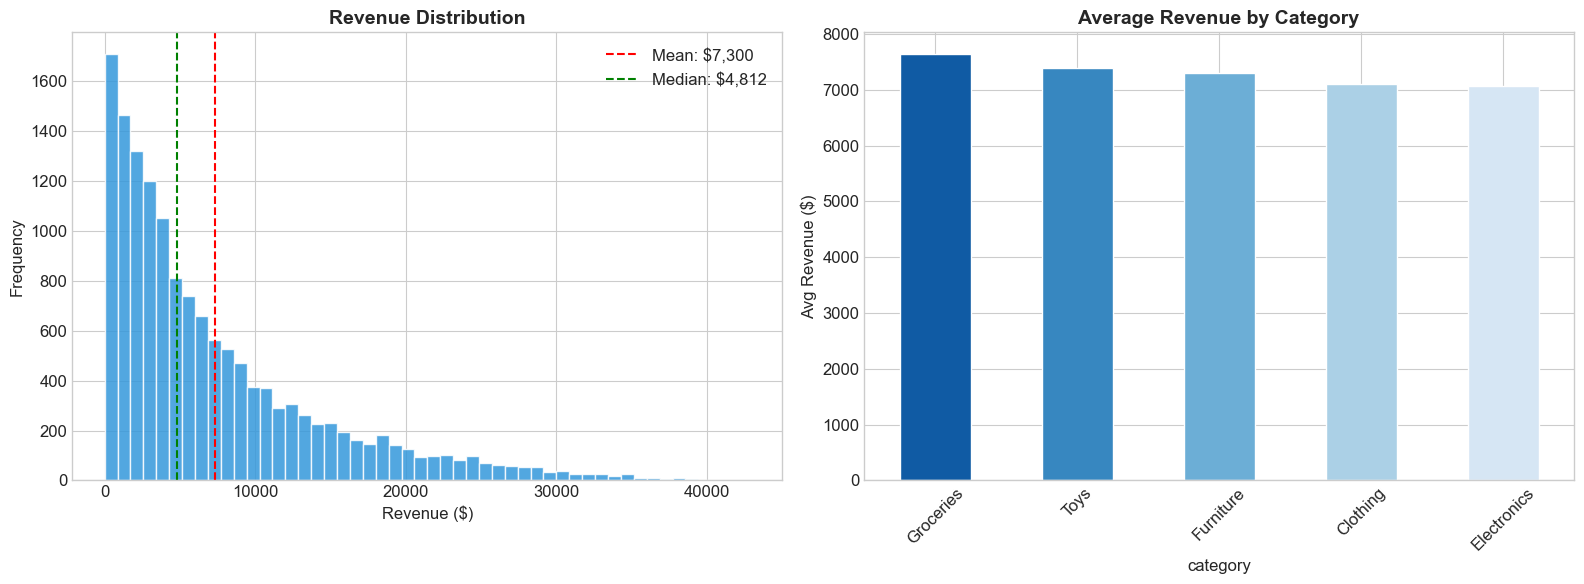

In [34]:
# ============================================================
# 6.1 Revenue Distribution
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(df['revenue'], bins=50, color='#3498db', edgecolor='white', alpha=0.85)
axes[0].set_title('Revenue Distribution', fontweight='bold')
axes[0].set_xlabel('Revenue ($)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['revenue'].mean(), color='red', linestyle='--', label=f"Mean: ${df['revenue'].mean():,.0f}")
axes[0].axvline(df['revenue'].median(), color='green', linestyle='--', label=f"Median: ${df['revenue'].median():,.0f}")
axes[0].legend()

# Revenue by category
cat_rev = df.groupby('category')['revenue'].mean().sort_values(ascending=False)
cat_rev.plot(kind='bar', ax=axes[1], color=sns.color_palette('Blues_r', len(cat_rev)),
             edgecolor='white')
axes[1].set_title('Average Revenue by Category', fontweight='bold')
axes[1].set_ylabel('Avg Revenue ($)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

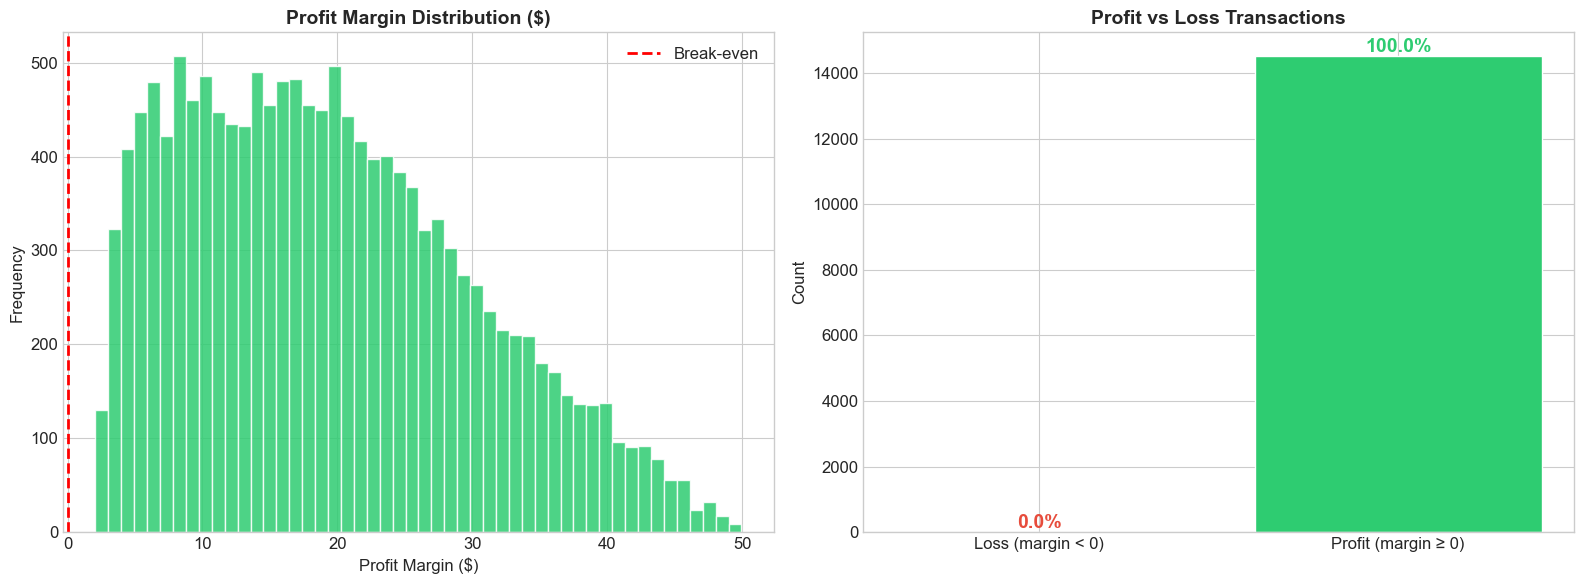

In [35]:
# ============================================================
# 6.2 Profit Margin Distribution & Analysis
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Profit Margin Distribution
axes[0].hist(df['profit_margin'], bins=50, color='#2ecc71', edgecolor='white', alpha=0.85)
axes[0].set_title('Profit Margin Distribution ($)', fontweight='bold')
axes[0].set_xlabel('Profit Margin ($)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(0, color='red', linestyle='--', linewidth=2, label='Break-even')
axes[0].legend()

# Number of loss vs profit transactions
loss_count = (df['profit_margin'] < 0).sum()
profit_count = (df['profit_margin'] >= 0).sum()
axes[1].bar(['Loss (margin < 0)', 'Profit (margin ≥ 0)'], [loss_count, profit_count],
            color=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[1].set_title('Profit vs Loss Transactions', fontweight='bold')
axes[1].set_ylabel('Count')

# Add percentage annotations
total = len(df)
axes[1].annotate(f'{loss_count/total*100:.1f}%', xy=(0, loss_count),
                 ha='center', va='bottom', fontsize=14, fontweight='bold', color='#e74c3c')
axes[1].annotate(f'{profit_count/total*100:.1f}%', xy=(1, profit_count),
                 ha='center', va='bottom', fontsize=14, fontweight='bold', color='#2ecc71')

plt.tight_layout()
plt.show()

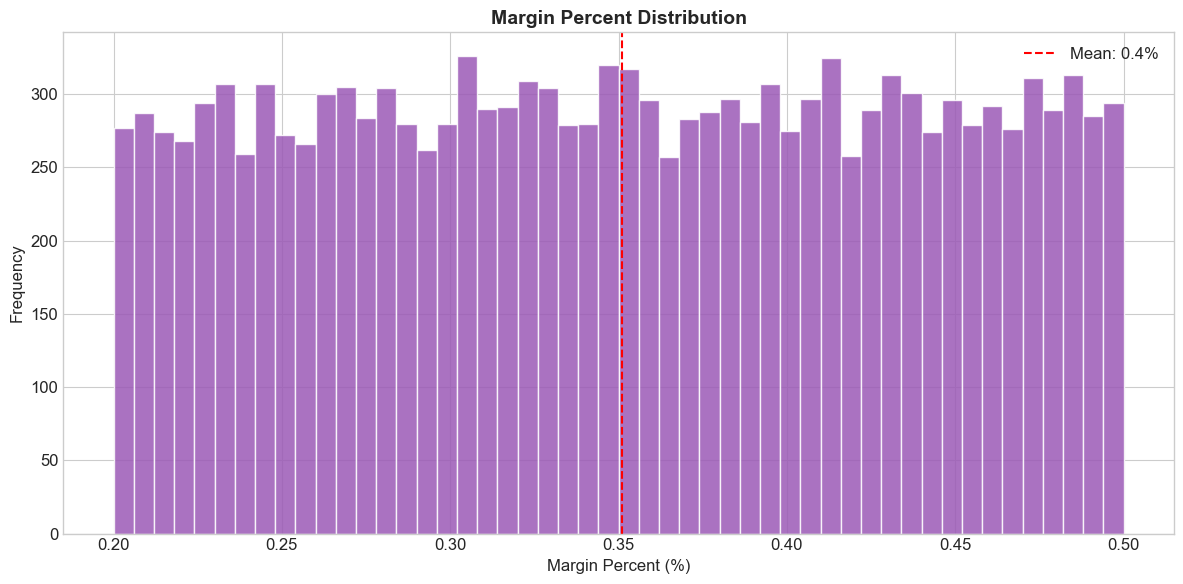

In [36]:
# ============================================================
# 6.3 Margin Percent Distribution
# ============================================================
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(df['margin_percent'], bins=50, color='#9b59b6', edgecolor='white', alpha=0.85)
ax.set_title('Margin Percent Distribution', fontweight='bold')
ax.set_xlabel('Margin Percent (%)')
ax.set_ylabel('Frequency')
ax.axvline(df['margin_percent'].mean(), color='red', linestyle='--',
           label=f"Mean: {df['margin_percent'].mean():.1f}%")
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

### 💡 Revenue & Profit Analysis – Insights

- **Revenue** is right-skewed – most transactions generate moderate revenue, but a few generate very high revenue.
- Some transactions result in **negative profit margins** – products sold below cost (possibly during promotions).
- The **average margin percent** gives an overall health check of the pricing strategy.
- Categories differ significantly in average revenue – high-value categories need different pricing strategies.
- An optimal pricing model should maximize revenue while maintaining healthy margins.

---

## 7️⃣ Time Series Analysis

In [37]:
# ============================================================
# 7.0 Parse Date Column
# ============================================================
df['date'] = pd.to_datetime(df['date'])
print(f'✅ Date range: {df["date"].min()} → {df["date"].max()}')

✅ Date range: 2022-01-01 00:00:00 → 2024-01-01 00:00:00


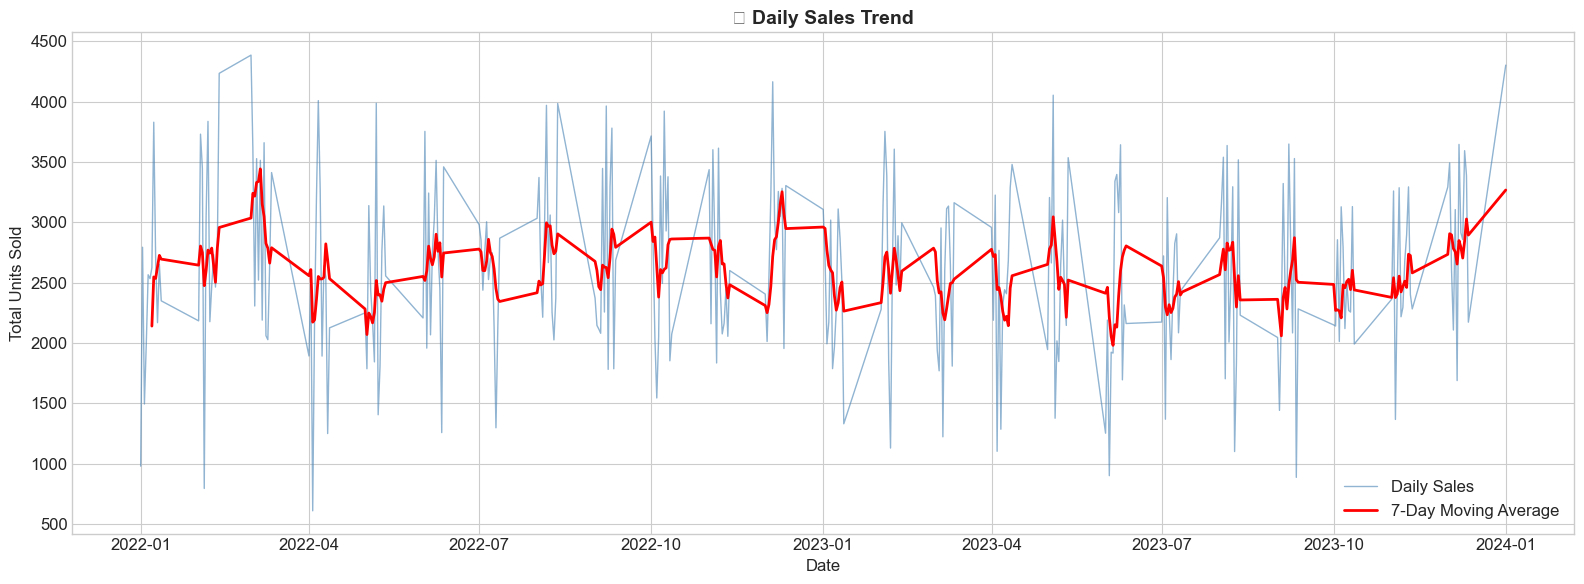

In [38]:
# ============================================================
# 7.1 Daily Sales Trend
# ============================================================
daily_sales = df.groupby('date')['units_sold'].sum().reset_index()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(daily_sales['date'], daily_sales['units_sold'], color='steelblue',
        linewidth=1, alpha=0.6, label='Daily Sales')

# 7-day rolling average
daily_sales['rolling_7'] = daily_sales['units_sold'].rolling(7).mean()
ax.plot(daily_sales['date'], daily_sales['rolling_7'], color='red',
        linewidth=2, label='7-Day Moving Average')

ax.set_title('📈 Daily Sales Trend', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Total Units Sold')
ax.legend()

plt.tight_layout()
plt.show()

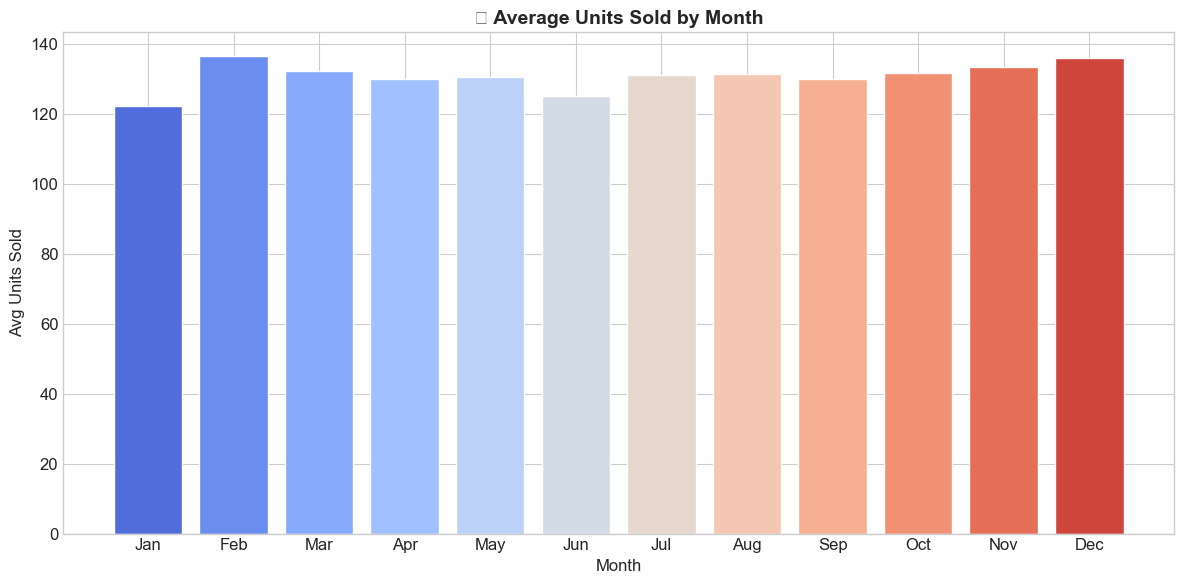

In [39]:
# ============================================================
# 7.2 Monthly Sales Trend
# ============================================================
monthly_sales = df.groupby('month')['units_sold'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(monthly_sales['month'], monthly_sales['units_sold'],
       color=sns.color_palette('coolwarm', 12), edgecolor='white')
ax.set_title('📅 Average Units Sold by Month', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Avg Units Sold')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

plt.tight_layout()
plt.show()

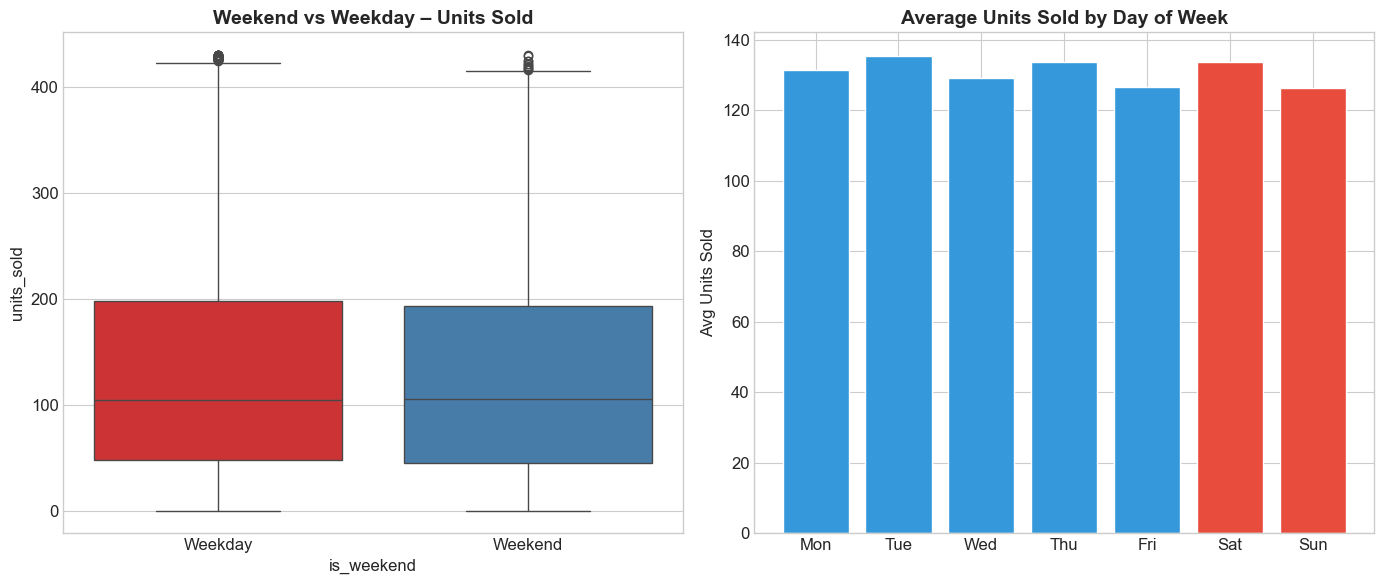

In [40]:
# ============================================================
# 7.3 Weekend vs Weekday Sales
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Box plot
sns.boxplot(data=df, x='is_weekend', y='units_sold', ax=axes[0], palette='Set1')
axes[0].set_title('Weekend vs Weekday – Units Sold', fontweight='bold')
axes[0].set_xticklabels(['Weekday', 'Weekend'])

# Day of week breakdown
dow_sales = df.groupby('day_of_week')['units_sold'].mean()
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_colors = ['#3498db'] * 5 + ['#e74c3c'] * 2
axes[1].bar(range(7), dow_sales.values, color=dow_colors, edgecolor='white')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(dow_labels)
axes[1].set_title('Average Units Sold by Day of Week', fontweight='bold')
axes[1].set_ylabel('Avg Units Sold')

plt.tight_layout()
plt.show()

### 💡 Time Series Analysis – Insights

- **Daily Trend**: Sales show fluctuations with visible patterns; the 7-day moving average smooths out noise.
- **Monthly Trend**: Certain months show higher average sales – aligns with seasonal patterns.
- **Weekend vs Weekday**: Sales patterns may differ between weekdays and weekends depending on the product category.
- **Day of Week**: Specific days may show consistently higher/lower sales – useful for promotional scheduling.

---

## 8️⃣ Advanced Engineered Feature Analysis

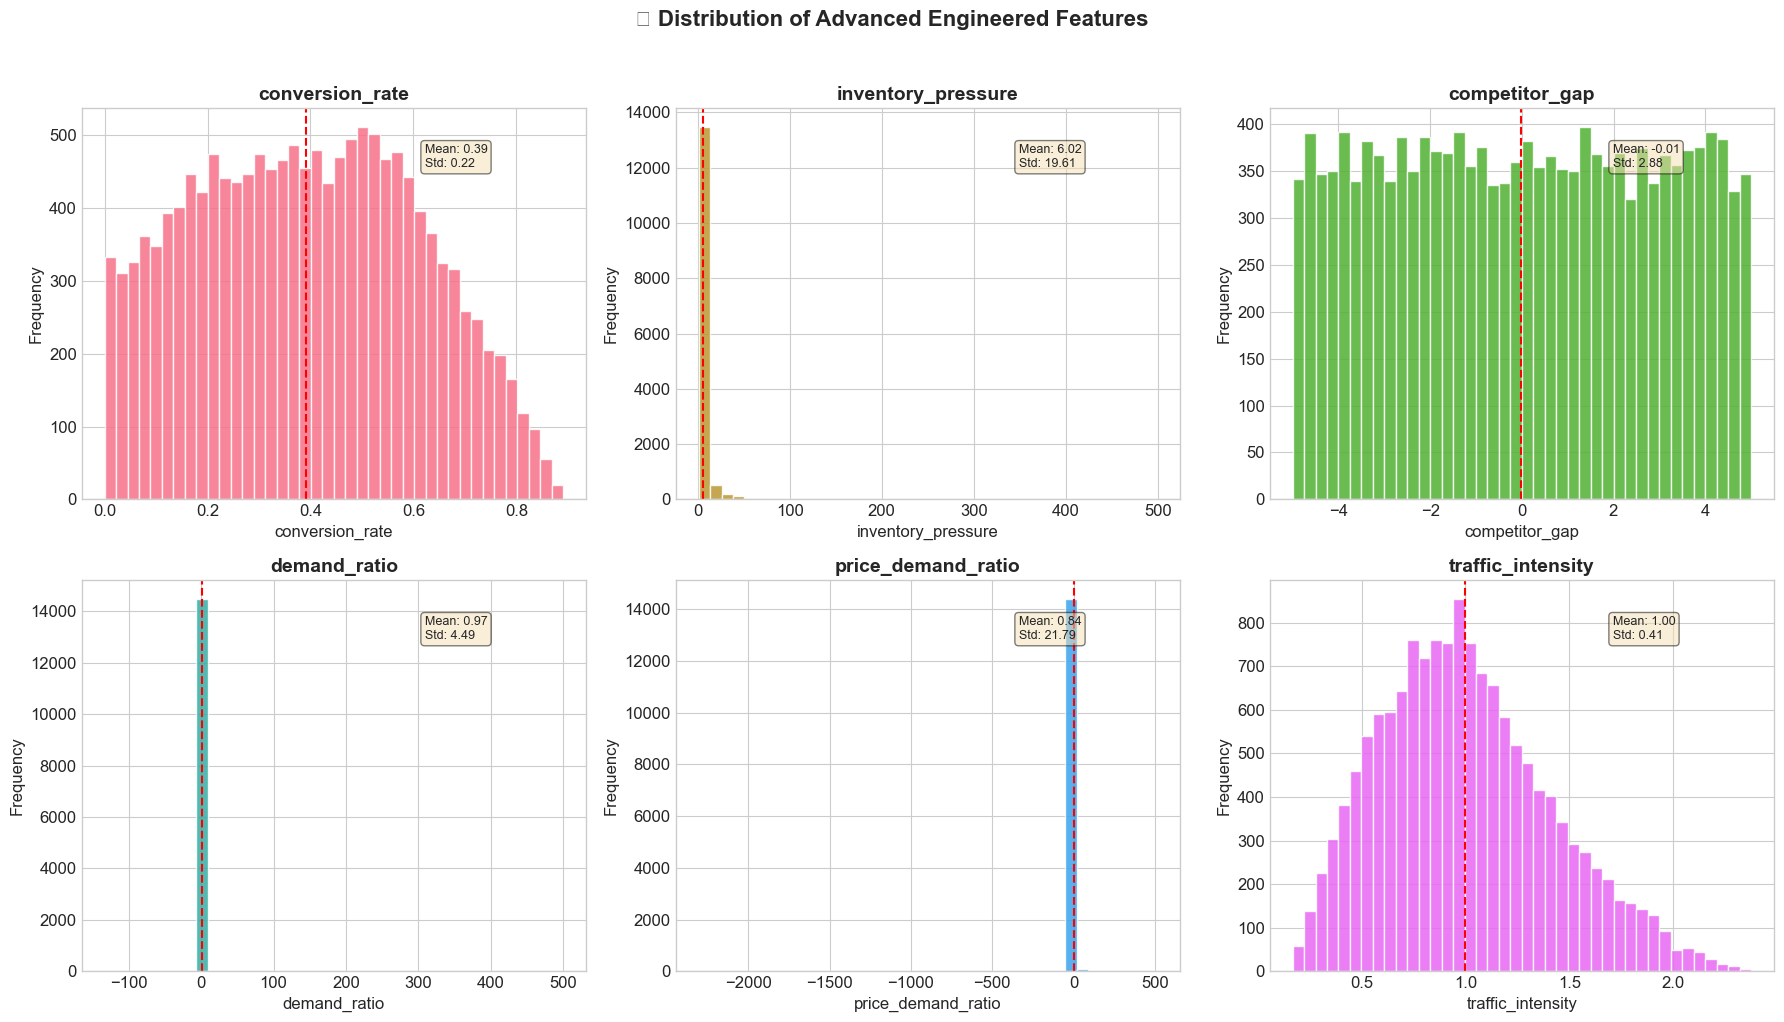

In [41]:
# ============================================================
# 8.1 Distribution of Advanced Features
# ============================================================
adv_features = ['conversion_rate', 'inventory_pressure', 'competitor_gap',
                'demand_ratio', 'price_demand_ratio', 'traffic_intensity']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('📊 Distribution of Advanced Engineered Features', fontsize=16, fontweight='bold', y=1.02)

colors = sns.color_palette('husl', len(adv_features))
for idx, col in enumerate(adv_features):
    ax = axes[idx // 3, idx % 3]
    ax.hist(df[col], bins=40, color=colors[idx], edgecolor='white', alpha=0.85)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    # Add stats
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5)
    ax.annotate(f'Mean: {df[col].mean():.2f}\nStd: {df[col].std():.2f}',
                xy=(0.68, 0.85), xycoords='axes fraction', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

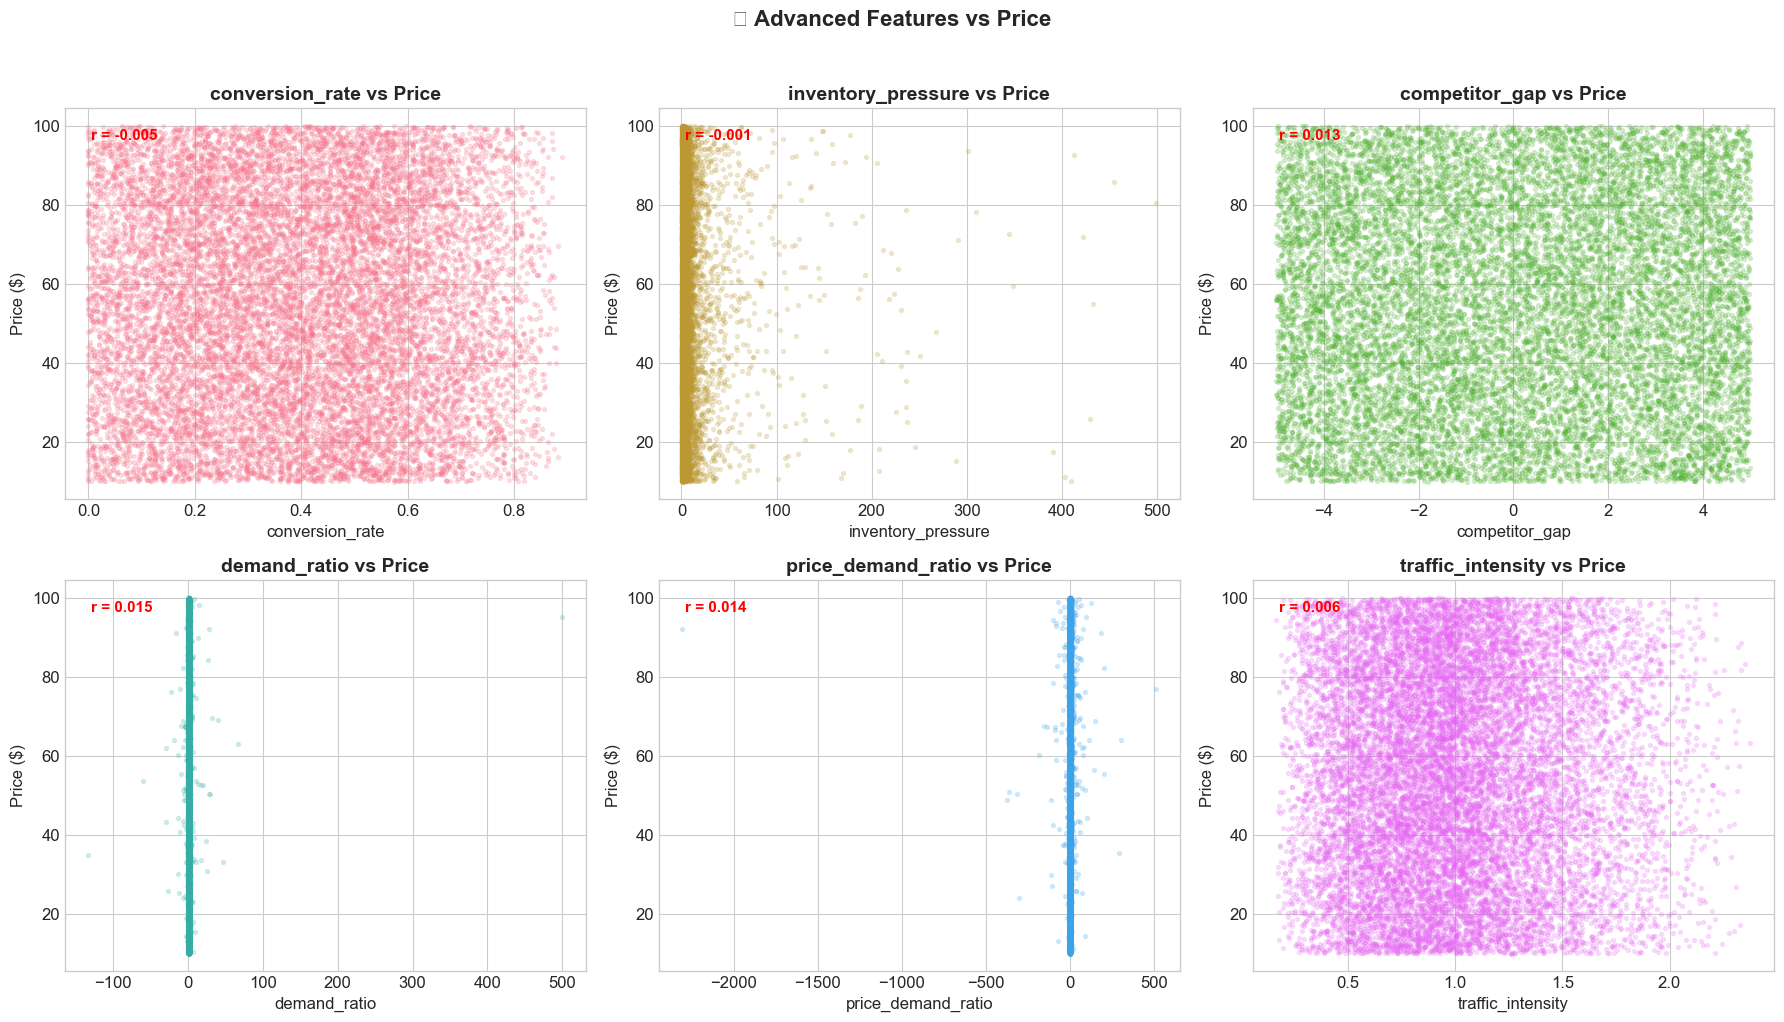

In [42]:
# ============================================================
# 8.2 Advanced Features vs Price (Scatter Matrix)
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('🔍 Advanced Features vs Price', fontsize=16, fontweight='bold', y=1.02)

for idx, col in enumerate(adv_features):
    ax = axes[idx // 3, idx % 3]
    ax.scatter(df[col], df['price'], alpha=0.2, s=8, c=colors[idx])
    ax.set_xlabel(col)
    ax.set_ylabel('Price ($)')
    ax.set_title(f'{col} vs Price', fontweight='bold')
    # Add correlation
    corr_val = df[col].corr(df['price'])
    ax.annotate(f'r = {corr_val:.3f}', xy=(0.05, 0.92), xycoords='axes fraction',
                fontsize=11, color='red', fontweight='bold')

plt.tight_layout()
plt.show()

### 💡 Advanced Feature Analysis – Insights

- **Conversion Rate**: Indicates how efficiently visitors are converted to buyers – key metric for pricing decisions.
- **Inventory Pressure**: Higher values indicate understocking – pricing can leverage scarcity.
- **Competitor Gap**: Shows how far our price is from competitors – negative means we're cheaper.
- **Demand Ratio**: Ratio of actual demand to forecasted demand – identifies under/over-demand situations.
- **Price-Demand Ratio**: Captures the relationship between price points and demand sensitivity.
- **Traffic Intensity**: Normalizes visitor count – helps identify high-traffic, low-conversion scenarios.

---

## 9️⃣ EDA Summary & Key Takeaways

### 📌 Major Findings

| # | Insight | Impact on Pricing |
|---|---------|-------------------|
| 1 | Higher prices reduce demand (classic demand curve) | Price optimization must balance revenue vs volume |
| 2 | Competitor pricing strongly influences our pricing | Market-aware pricing is essential |
| 3 | Promotions boost sales significantly | Strategic promotions can drive volume |
| 4 | Seasonal patterns exist in sales | Dynamic pricing should adapt to seasons |
| 5 | Some products are sold at a loss | Need pricing floors to prevent losses |
| 6 | Cost is a major determinant of price | Cost-plus remains a baseline strategy |
| 7 | Regional differences in demand | Location-based pricing can optimize revenue |
| 8 | Traffic and conversion rates vary widely | Price can be tuned based on conversion potential |

### 🎯 Features Most Important for Price Prediction
1. `competitor_pricing` – strongest market signal
2. `cost` – production cost baseline
3. `discounted_price` – actual effective price
4. `demand_forecast` – expected demand
5. `profit_margin` / `margin_percent` – profitability targets

### ⚠️ Considerations for Modeling
- Drop highly correlated redundant features to avoid multicollinearity
- Encode categorical features (category, region, seasonality, weather)
- Consider log-transforming skewed features
- `date` column should be dropped (temporal info captured via day_of_week, month, is_weekend)

---
**Next Step →** Data Preparation & Model Training